# Indicators, tables and figures

Takes your saved Pareto fronts and produces HV / IGD / SP, the two required
tables, the Wilcoxon tests, and the figures.

## Input

One CSV, `runs.csv`, holding the final fronts of every run. **One row per
Pareto point**, not per run — a run returning 40 points contributes 40 rows,
repeating the instance, algorithm, seed and runtime on each:

```
instance,algorithm,seed,runtime_s,f1,f2
X-n110-k13,NSGA-II,1,120.0,14321,10713.49
X-n110-k13,NSGA-II,1,120.0,14484,10497.08
X-n110-k13,NSGA-II,1,120.0,14632,10341.72
...
X-n110-k13,NSGA-II,2,120.0,14298,10802.31
...
X-n110-k13,Weighted-sum,1,119.4,14264,10944.02
```

| column | |
|---|---|
| `instance` | `X-n101-k25`, `X-n106-k14`, `X-n110-k13`, `X-n115-k10` |
| `algorithm` | `NSGA-II` or `Weighted-sum`, spelled exactly as in `ALGORITHMS` below |
| `seed` | 1–20; the same 20 seeds must appear for both algorithms so the runs pair up |
| `runtime_s` | wall-clock seconds for that run |
| `f1` | total distance of that Pareto point, original units |
| `f2` | total CO₂ of that Pareto point, kg, original units |

Raw units, not normalised. Final fronts only, not intermediate generations.

## Writing it

```python
import csv, time

with open("runs.csv", "w", newline="") as fh:
    w = csv.writer(fh)
    w.writerow(["instance", "algorithm", "seed", "runtime_s", "f1", "f2"])

    for instance in ["X-n101-k25", "X-n106-k14", "X-n110-k13", "X-n115-k10"]:
        for algorithm in ["NSGA-II", "Weighted-sum"]:
            for seed in range(1, 21):

                t0 = time.perf_counter()
                front = run_my_solver(instance, algorithm, seed)   # <- your code
                runtime = time.perf_counter() - t0

                # front: the final non-dominated solutions of this run.
                # Write one row per point, in original units.
                for sol in front:
                    w.writerow([instance, algorithm, seed, round(runtime, 1),
                                sol.distance, sol.co2])

                fh.flush()      # so a crash at seed 17 keeps seeds 1-16
```

If your solver returns routes rather than objective values, score them first
with the evaluator that passed `verify_benchmark.ipynb`.

## 0. Setup

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

RUNS_CSV = "results/runs.csv"       # your saved fronts
OUT_DIR  = "results/analysis_out"   # tables and figures are written here

import os
os.makedirs(OUT_DIR, exist_ok=True)

# Order used in every table and plot.
ALGORITHMS = ["NSGA-II", "Weighted-sum"]

## 1. Load and check

In [24]:
df = pd.read_csv(RUNS_CSV)

required = {"instance", "algorithm", "seed", "f1", "f2"}
missing = required - set(df.columns)
assert not missing, f"runs.csv is missing columns: {missing}"

instances = sorted(df["instance"].unique())
print("instances :", instances)
print("algorithms:", sorted(df["algorithm"].unique()))
print("rows      :", len(df))

for a in ALGORITHMS:
    assert a in set(df["algorithm"]), f"no rows for algorithm {a!r}"

# Every instance x algorithm must have the same seed set, or the paired
# Wilcoxon test is not valid.
for inst in instances:
    seedsets = {}
    for a in ALGORITHMS:
        s = df[(df.instance == inst) & (df.algorithm == a)]["seed"]
        seedsets[a] = set(s.unique())
    if seedsets[ALGORITHMS[0]] != seedsets[ALGORITHMS[1]]:
        d0 = seedsets[ALGORITHMS[0]] - seedsets[ALGORITHMS[1]]
        d1 = seedsets[ALGORITHMS[1]] - seedsets[ALGORITHMS[0]]
        raise AssertionError(f"{inst}: seed sets differ (only in "
                             f"{ALGORITHMS[0]}: {sorted(d0)}, only in {ALGORITHMS[1]}: {sorted(d1)})")
    n = len(seedsets[ALGORITHMS[0]])
    print(f"  {inst}: {n} paired seeds")
    if n != 20:
        print(f"    NOTE: expected 20 seeds, found {n}")

empty = df.groupby(["instance", "algorithm", "seed"]).size()
assert (empty > 0).all(), "some runs have no points"

instances : ['X-n101-k25', 'X-n106-k14', 'X-n110-k13', 'X-n115-k10', 'X-n143-k7', 'X-n172-k51', 'X-n200-k36', 'X-n237-k14', 'X-n261-k13', 'X-n313-k71']
algorithms: ['NSGA-II', 'Weighted-sum']
rows      : 18596
  X-n101-k25: 20 paired seeds
  X-n106-k14: 20 paired seeds
  X-n110-k13: 20 paired seeds
  X-n115-k10: 20 paired seeds
  X-n143-k7: 20 paired seeds
  X-n172-k51: 20 paired seeds
  X-n200-k36: 20 paired seeds
  X-n237-k14: 20 paired seeds
  X-n261-k13: 20 paired seeds
  X-n313-k71: 20 paired seeds


## 2. Indicators

- **dominance** — $p$ dominates $q$ when $p_1 \le q_1$, $p_2 \le q_2$, one strict.
  Duplicates removed.
- **HV** — dominated area in normalised space up to $(1.1, 1.1)$. Higher better.
- **IGD** — mean Euclidean distance from each reference-front point to the
  nearest front point. Lower better.
- **SP** — sample SD ($N-1$) of nearest-neighbour Manhattan distances. Lower
  better; `nan` when $N < 2$.

In [25]:
def nondominated(P):
    P = np.asarray(P, dtype=float)
    if len(P) == 0:
        return P
    keep = np.ones(len(P), bool)
    for i in range(len(P)):
        if not keep[i]:
            continue
        dom = np.all(P <= P[i], axis=1) & np.any(P < P[i], axis=1)
        dom[i] = False
        if dom.any():
            keep[i] = False
    return np.unique(P[keep], axis=0)


def hypervolume(P, ref=(1.1, 1.1)):
    P = nondominated(P)
    P = P[(P[:, 0] < ref[0]) & (P[:, 1] < ref[1])]
    if len(P) == 0:
        return 0.0
    P = P[np.argsort(P[:, 0])]
    hv, prev_f2 = 0.0, ref[1]
    for x, y in P:
        hv += (ref[0] - x) * (prev_f2 - y)
        prev_f2 = y
    return float(hv)


def igd(P, R):
    P = np.asarray(P, float)
    R = np.asarray(R, float)
    if len(P) == 0:
        return float("nan")
    d = np.sqrt(((R[:, None, :] - P[None, :, :]) ** 2).sum(-1))
    return float(d.min(axis=1).mean())


def spacing(P):
    P = np.asarray(P, float)
    N = len(P)
    if N < 2:
        return float("nan")           # undefined, not zero
    M = np.abs(P[:, None, :] - P[None, :, :]).sum(-1)
    np.fill_diagonal(M, np.inf)
    d = M.min(axis=1)
    return float(np.sqrt(((d - d.mean()) ** 2).sum() / (N - 1)))

## 3. Normalisation and the reference front

Bounds per instance over every point from every algorithm and seed, the same
bounds for both algorithms. IGD reference front: the non-dominated union of all
normalised fronts on that instance.

Both depend on which algorithms are included — adding a third shifts every HV
and IGD value.

In [26]:
def normalise(F, zmin, zmax):
    return (np.asarray(F, float) - zmin) / (zmax - zmin)


print(f"normalisation and IGD reference front computed over: {ALGORITHMS}")
print("(adding or removing an algorithm changes every HV and IGD value)\n")

per_instance = {}
for inst in instances:
    sub = df[(df.instance == inst) & (df.algorithm.isin(ALGORITHMS))]
    allpts = sub[["f1", "f2"]].to_numpy(float)
    zmin, zmax = allpts.min(0), allpts.max(0)

    fronts = {}
    for (a, s), g in sub.groupby(["algorithm", "seed"]):
        fronts[(a, int(s))] = g[["f1", "f2"]].to_numpy(float)

    ref = nondominated(np.vstack([normalise(F, zmin, zmax) for F in fronts.values()]))

    per_instance[inst] = dict(zmin=zmin, zmax=zmax, fronts=fronts, ref=ref)
    print(f"{inst}: f1 in [{zmin[0]:.0f}, {zmax[0]:.0f}]   "
          f"f2 in [{zmin[1]:.1f}, {zmax[1]:.1f}]   |R| = {len(ref)}")

normalisation and IGD reference front computed over: ['NSGA-II', 'Weighted-sum']
(adding or removing an algorithm changes every HV and IGD value)

X-n101-k25: f1 in [25577, 30852]   f2 in [11794.1, 21994.4]   |R| = 156
X-n106-k14: f1 in [23620, 29513]   f2 in [11233.2, 20548.0]   |R| = 142
X-n110-k13: f1 in [14150, 16280]   f2 in [6225.6, 12201.5]   |R| = 127
X-n115-k10: f1 in [12194, 13922]   f2 in [5238.5, 9723.3]   |R| = 91
X-n143-k7: f1 in [14887, 17170]   f2 in [6575.7, 12845.5]   |R| = 112
X-n172-k51: f1 in [41975, 53535]   f2 in [20407.8, 36171.0]   |R| = 171
X-n200-k36: f1 in [54169, 67424]   f2 in [25790.9, 47469.5]   |R| = 142
X-n237-k14: f1 in [25353, 30284]   f2 in [11427.9, 22278.0]   |R| = 129
X-n261-k13: f1 in [25260, 30312]   f2 in [11352.6, 22277.3]   |R| = 107
X-n313-k71: f1 in [87895, 109598]   f2 in [41838.8, 76269.9]   |R| = 135


## 4. Run-level indicators

One row per instance, algorithm, seed.

In [27]:
rows = []
for inst in instances:
    d = per_instance[inst]
    for (a, s), F in d["fronts"].items():
        Fnd = nondominated(F)
        Nn = nondominated(normalise(F, d["zmin"], d["zmax"]))
        rt = df[(df.instance == inst) & (df.algorithm == a) & (df.seed == s)]
        rows.append(dict(
            instance=inst, algorithm=a, seed=s,
            runtime_s=float(rt["runtime_s"].iloc[0]) if "runtime_s" in df.columns else np.nan,
            HV=hypervolume(Nn),
            IGD=igd(Nn, d["ref"]),
            SP=spacing(Nn),
            **{"|P|": len(Fnd)},
            best_distance=float(Fnd[:, 0].min()),
            best_co2=float(Fnd[:, 1].min()),
        ))

runs = pd.DataFrame(rows).sort_values(["instance", "algorithm", "seed"]).reset_index(drop=True)
runs.to_csv(f"{OUT_DIR}/run_level_indicators.csv", index=False)
print(f"wrote {OUT_DIR}/run_level_indicators.csv")
runs.head(8)

wrote results/analysis_out/run_level_indicators.csv


,instance,algorithm,seed,runtime_s,HV,IGD,SP,|P|,best_distance,best_co2
0,X-n101-k25,NSGA-II,1,119.9,0.809636,0.012251,0.010799,82,25667.0,11834.2141
1,X-n101-k25,NSGA-II,2,119.8,0.808224,0.012108,0.012979,80,25639.0,11829.5763
2,X-n101-k25,NSGA-II,3,119.8,0.797792,0.017556,0.010715,78,25727.0,11810.9005
3,X-n101-k25,NSGA-II,4,119.8,0.794102,0.018812,0.009753,88,25727.0,11829.5763
4,X-n101-k25,NSGA-II,5,119.8,0.800387,0.015639,0.011309,86,25692.0,11820.2293
5,X-n101-k25,NSGA-II,6,119.9,0.783613,0.024797,0.011725,97,25800.0,11807.5888
6,X-n101-k25,NSGA-II,7,119.8,0.790436,0.021957,0.008955,90,25709.0,11800.4021
7,X-n101-k25,NSGA-II,8,119.8,0.790653,0.023312,0.009351,96,25642.0,11794.4055


## 5. Distribution summary

Mean, SD, median and IQR over the seeds. `nan` excluded; `n` is the usable-run
count.

In [28]:
METRICS = ["HV", "IGD", "SP", "|P|", "best_distance", "best_co2"]
LABEL = {"HV": r"HV $\uparrow$", "IGD": r"IGD $\downarrow$", "SP": r"SP $\downarrow$",
         "|P|": r"$|\mathcal{P}|$ $\uparrow$",
         "best_distance": r"Best distance $\downarrow$",
         "best_co2": r"Best CO$_2$ $\downarrow$"}

summary = []
for inst in instances:
    for a in ALGORITHMS:
        g = runs[(runs.instance == inst) & (runs.algorithm == a)]
        for m in METRICS:
            v = g[m].dropna().to_numpy(float)
            summary.append(dict(
                instance=inst, algorithm=a, metric=m, n=len(v),
                mean=v.mean(), sd=v.std(ddof=1),
                median=np.median(v),
                iqr=np.percentile(v, 75) - np.percentile(v, 25),
            ))

summary = pd.DataFrame(summary)
summary.to_csv(f"{OUT_DIR}/distribution_summary.csv", index=False)

short = summary[summary.n < runs.groupby(["instance", "algorithm"]).size().max()]
if len(short):
    print("metrics computed from fewer runs than available (nan dropped):")
    print(short[["instance", "algorithm", "metric", "n"]].to_string(index=False))
else:
    print("all metrics use every run")

summary.head(6)

all metrics use every run


,instance,algorithm,metric,n,mean,sd,median,iqr
0,X-n101-k25,NSGA-II,HV,20,0.798251,0.009082,0.799073,0.009421
1,X-n101-k25,NSGA-II,IGD,20,0.017841,0.005576,0.016829,0.006846
2,X-n101-k25,NSGA-II,SP,20,0.011224,0.001372,0.011280,0.002011
3,X-n101-k25,NSGA-II,|P|,20,87.050000,9.017381,85.500000,16.500000
4,X-n101-k25,NSGA-II,best_distance,20,25701.100000,63.576643,25696.000000,79.500000
5,X-n101-k25,NSGA-II,best_co2,20,11811.131855,12.811710,11807.588800,18.781850


## 6. Wilcoxon signed-rank tests

Two-sided, paired by seed index.

In [29]:
def stars(p):
    return "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"

tests = []
for inst in instances:
    for m in ["HV", "IGD", "SP"]:
        a = runs[(runs.instance == inst) & (runs.algorithm == ALGORITHMS[0])].set_index("seed")[m]
        b = runs[(runs.instance == inst) & (runs.algorithm == ALGORITHMS[1])].set_index("seed")[m]
        pair = pd.concat([a, b], axis=1, keys=["a", "b"]).dropna()
        if len(pair) < 1 or np.allclose(pair.a, pair.b):
            stat, p = np.nan, 1.0
        else:
            stat, p = wilcoxon(pair.a, pair.b, alternative="two-sided")
        tests.append(dict(instance=inst, metric=m, n_pairs=len(pair),
                          p=float(p), sig=stars(p),
                          median_diff=float(np.median(pair.a - pair.b)) if len(pair) else np.nan))

tests = pd.DataFrame(tests)
tests.to_csv(f"{OUT_DIR}/wilcoxon.csv", index=False)
tests

,instance,metric,n_pairs,p,sig,median_diff
0,X-n101-k25,HV,20,0.000002,***,0.035285
1,X-n101-k25,IGD,20,0.000002,***,-0.025543
2,X-n101-k25,SP,20,0.000002,***,-0.048430
3,X-n106-k14,HV,20,0.000002,***,0.053288
4,X-n106-k14,IGD,20,0.000002,***,-0.069457
5,X-n106-k14,SP,20,0.000002,***,-0.120018
6,X-n110-k13,HV,20,0.000002,***,0.099194
7,X-n110-k13,IGD,20,0.000002,***,-0.059597
8,X-n110-k13,SP,20,0.000002,***,-0.066182
9,X-n115-k10,HV,20,0.000002,***,0.033832


## 7. LaTeX tables

Written to `.tex` files you can `\input` directly.

In [30]:
def fmt(v, m):
    if not np.isfinite(v):
        return "---"
    if m in ("best_distance",):
        return f"{v:.0f}"
    if m in ("best_co2",):
        return f"{v:.1f}"
    if m == "|P|":
        return f"{v:.1f}"
    return f"{v:.4f}"


# names used in the tables (the data itself keeps the plain "NSGA-II")
TABLE_NAME = {"NSGA-II": "Memetic NSGA-II", "Weighted-sum": "Weighted-sum"}
CAPTION_NAME = {"NSGA-II": "memetic NSGA-II", "Weighted-sum": "Weighted-sum"}

# metrics where a larger value is better; all others are smaller-is-better
HIGHER_IS_BETTER = {"HV", "|P|"}


def best_values(values, m):
    """Formatted strings of the best value(s) among `values` for metric m.
    Compared after rounding, so values that print the same are all bold."""
    shown = {fmt(v, m): v for v in values if np.isfinite(v)}
    if not shown:
        return set()
    pick = max if m in HIGHER_IS_BETTER else min
    best = pick(shown.values())
    return {s for s, v in shown.items() if s == fmt(best, m)}


def num(v, m, best):
    s = fmt(v, m)
    return r"\mathbf{%s}" % s if s in best else s


def summary_table_tex():
    L = [r"\begin{table}[htbp]", r"\centering",
         r"\caption{Distribution statistics over the seeds, both algorithms side by side. "
         r"Arrows give the preferred direction.}",
         r"\label{tab:my_summary}", r"\small",
         r"\setlength{\tabcolsep}{4pt}",
         r"\resizebox{\textwidth}{!}{%",
         r"\begin{tabular}{ll cc cc}", r"\toprule",
         r"& & \multicolumn{2}{c}{%s} & \multicolumn{2}{c}{%s} \\" % tuple(TABLE_NAME[a] for a in ALGORITHMS),
         r"\cmidrule(lr){3-4}\cmidrule(lr){5-6}",
         r"Instance & Metric & Median (IQR) & Mean (SD) & Median (IQR) & Mean (SD) \\",
         r"\midrule"]
    for k, inst in enumerate(instances):
        if k:
            L.append(r"\midrule")
        for j, m in enumerate(METRICS):
            rows = [summary[(summary.instance == inst) & (summary.algorithm == a)
                            & (summary.metric == m)].iloc[0] for a in ALGORITHMS]
            # bold the best median and the best mean of the row
            best_median = best_values([r["median"] for r in rows], m)
            best_mean = best_values([r["mean"] for r in rows], m)
            cells_ = []
            for r in rows:
                cells_ += [f"${num(r['median'], m, best_median)}$ (${fmt(r['iqr'], m)}$)",
                           f"${num(r['mean'], m, best_mean)}$ (${fmt(r['sd'], m)}$)"]
            first = r"\texttt{%s}" % inst if j == 0 else ""
            L.append(f"{first} & {LABEL[m]} & " + " & ".join(cells_) + r" \\")
    L += [r"\bottomrule", r"\end{tabular}}", r"\end{table}"]
    return "\n".join(L)


def wilcoxon_table_tex():
    L = [r"\begin{table}[htbp]", r"\centering",
         r"\caption{Wilcoxon signed-rank tests comparing %s and %s over paired runs. "
         r"Tests are two-sided.}" % tuple(CAPTION_NAME[a] for a in ALGORITHMS),
         r"\label{tab:my_wilcoxon}",
         r"\begin{tabular}{lcccccc}", r"\toprule",
         r"Instance & HV $p$ & HV sig. & IGD $p$ & IGD sig. & SP $p$ & SP sig. \\",
         r"\midrule"]
    for inst in instances:
        row = [r"\texttt{%s}" % inst]
        for m in ["HV", "IGD", "SP"]:
            t = tests[(tests.instance == inst) & (tests.metric == m)].iloc[0]
            row += [r"$<0.0001$" if t.p < 1e-4 else f"${t.p:.4f}$", t.sig]
        L.append(" & ".join(row) + r" \\")
    L += [r"\bottomrule", r"\end{tabular}", r"\end{table}"]
    return "\n".join(L)


open(f"{OUT_DIR}/table_summary.tex", "w").write(summary_table_tex() + "\n")
open(f"{OUT_DIR}/table_wilcoxon.tex", "w").write(wilcoxon_table_tex() + "\n")
print(f"wrote {OUT_DIR}/table_summary.tex and {OUT_DIR}/table_wilcoxon.tex")
print()
print(summary_table_tex()[:700], "...")

wrote results/analysis_out/table_summary.tex and results/analysis_out/table_wilcoxon.tex

\begin{table}[htbp]
\centering
\caption{Distribution statistics over the seeds, both algorithms side by side. Arrows give the preferred direction.}
\label{tab:my_summary}
\small
\setlength{\tabcolsep}{4pt}
\resizebox{\textwidth}{!}{%
\begin{tabular}{ll cc cc}
\toprule
& & \multicolumn{2}{c}{Memetic NSGA-II} & \multicolumn{2}{c}{Weighted-sum} \\
\cmidrule(lr){3-4}\cmidrule(lr){5-6}
Instance & Metric & Median (IQR) & Mean (SD) & Median (IQR) & Mean (SD) \\
\midrule
\texttt{X-n101-k25} & HV $\uparrow$ & $\mathbf{0.7991}$ ($0.0094$) & $\mathbf{0.7983}$ ($0.0091$) & $0.7631$ ($0.0097$) & $0.7629$ ($0.0089$) \\
 & IGD $\downarrow$ & $\mathbf{0.0168}$ ($0.0068$) & $\mathbf{0.0178}$ ($0.0056$) & $0. ...


## 8. Figures

Fronts are plotted in original units; indicators in normalised space.

wrote results/analysis_out/boxplots.pdf


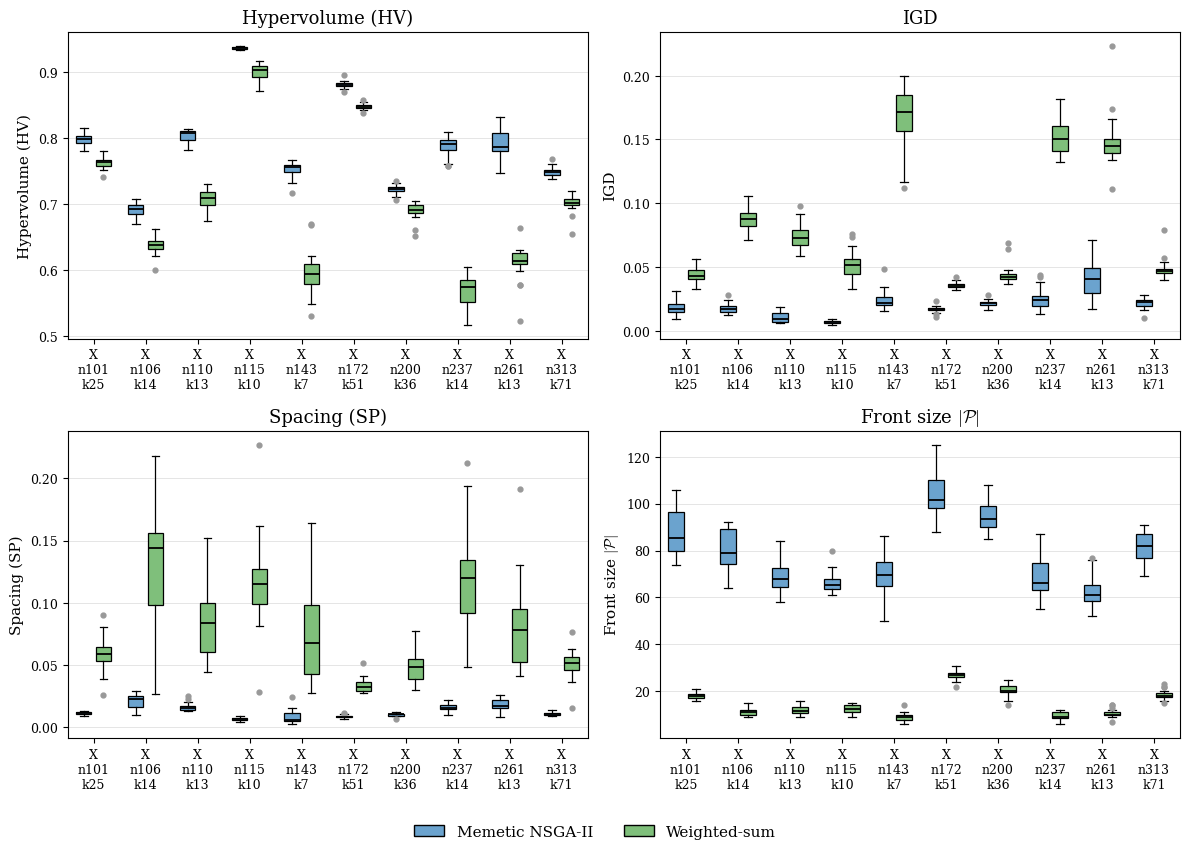

In [31]:
import matplotlib as mpl
from matplotlib.patches import Patch

# ---- styling to match the reference figure ------------------------------
mpl.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "axes.grid": True,
    "grid.color": "0.88",
    "grid.linewidth": 0.6,
})

COLOURS = {"NSGA-II": "#6BA3CE", "Weighted-sum": "#7FBF7B"}
LEGEND = {"NSGA-II": "Memetic NSGA-II", "Weighted-sum": "Weighted-sum"}
METRICS = [("HV", "Hypervolume (HV)"),
           ("IGD", "IGD"),
           ("SP", "Spacing (SP)"),
           ("|P|", r"Front size $|\mathcal{P}|$")]

WIDTH, OFFSET = 0.30, 0.19    


def tick_label(name):
    """'X-n101-k25' -> 'X\nn101\nk25', as in the reference figure."""
    return "\n".join(name.split("-"))


fig, axes = plt.subplots(2, 2, figsize=(12, 8.5))

for ax, (metric, title) in zip(axes.flat, METRICS):
    for k, algo in enumerate(ALGORITHMS):
        data, pos = [], []
        for j, inst in enumerate(instances):
            v = runs[(runs.instance == inst) &
                     (runs.algorithm == algo)][metric].dropna().to_numpy()
            if len(v):
                data.append(v)
                pos.append(j + (k - 0.5) * 2 * OFFSET)
        if not data:
            continue

        bp = ax.boxplot(
            data, positions=pos, widths=WIDTH, patch_artist=True,
            flierprops=dict(marker="o", markersize=3.5,
                            markerfacecolor="0.6", markeredgecolor="0.6",
                            linestyle="none"),
            medianprops=dict(color="black", linewidth=1.3),
            whiskerprops=dict(color="black", linewidth=0.9),
            capprops=dict(color="black", linewidth=0.9),
            boxprops=dict(edgecolor="black", linewidth=0.9),
        )
        for patch in bp["boxes"]:
            patch.set_facecolor(COLOURS[algo])

    ax.set_title(title, fontsize=13)
    ax.set_ylabel(title, fontsize=11)
    ax.set_xticks(range(len(instances)))
    ax.set_xticklabels([tick_label(i) for i in instances], fontsize=10)
    ax.set_xlim(-0.5, len(instances) - 0.5)
    ax.tick_params(labelsize=9)
    ax.set_axisbelow(True)
    ax.grid(axis="x", visible=False)

handles = [Patch(facecolor=COLOURS[a], edgecolor="black", label=LEGEND[a])
           for a in ALGORITHMS]
fig.legend(handles=handles, loc="lower center", ncol=2, frameon=False,
           fontsize=11, bbox_to_anchor=(0.5, -0.01))

fig.tight_layout(rect=(0, 0.045, 1, 1))
fig.savefig(f"{OUT_DIR}/boxplots.pdf", bbox_inches="tight")
print(f"wrote {OUT_DIR}/boxplots.pdf")
plt.show()

In [32]:
# fig, axes = plt.subplots(len(["HV", "IGD", "SP", "|P|"]), len(instances),
#                          figsize=(3.2 * len(instances), 9), squeeze=False)
# for i, m in enumerate(["HV", "IGD", "SP", "|P|"]):
#     for j, inst in enumerate(instances):
#         ax = axes[i][j]
#         data = [runs[(runs.instance == inst) & (runs.algorithm == a)][m].dropna().to_numpy()
#                 for a in ALGORITHMS]
#         ax.boxplot(data, labels=[a.replace("-", "-\n") for a in ALGORITHMS])
#         if j == 0:
#             ax.set_ylabel(m)
#         if i == 0:
#             ax.set_title(inst, fontsize=10)
#         ax.tick_params(labelsize=8)
# fig.tight_layout()
# fig.savefig(f"{OUT_DIR}/boxplots.pdf")
# print(f"wrote {OUT_DIR}/boxplots.pdf")
# plt.show()

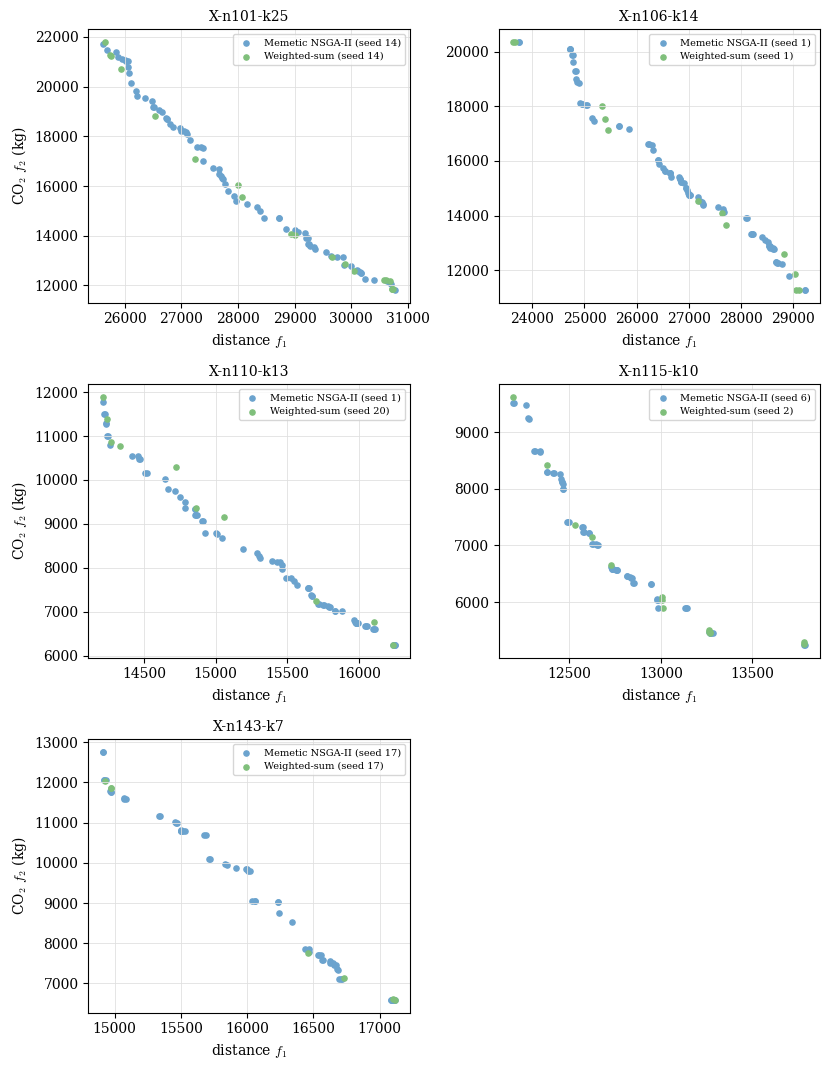

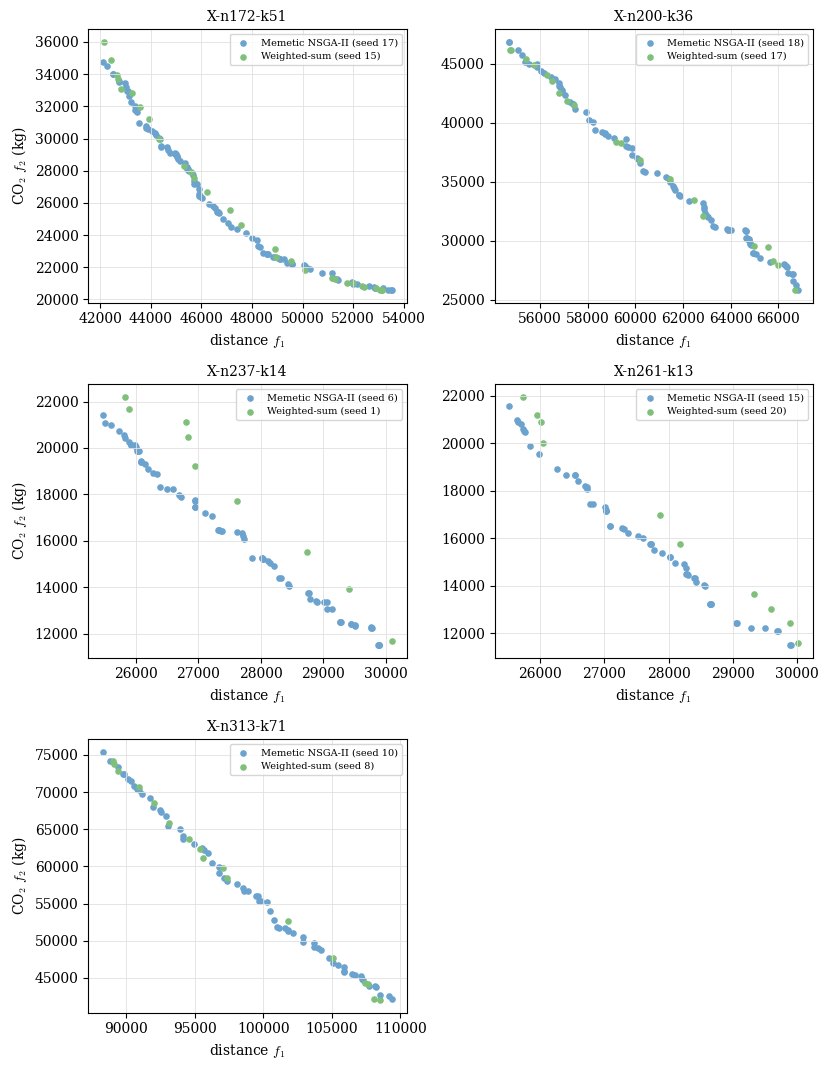

wrote results/analysis_out/median_pareto_fronts_memetic_NSGA-II_part1.pdf, results/analysis_out/median_pareto_fronts_memetic_NSGA-II_part2.pdf and median_run_seeds.csv


In [33]:
import math
from matplotlib.gridspec import GridSpec

COLOURS = {"NSGA-II": "#6BA3CE", "Weighted-sum": "#7FBF7B"}  # same as the boxplot legend
LEGEND = {"NSGA-II": "Memetic NSGA-II", "Weighted-sum": "Weighted-sum"}  # same names as the boxplot legend
N_FIGURES = 2   # instances are split over this many PDFs, so each fits on one LaTeX page

n_cols = 2
per_fig = math.ceil(len(instances) / N_FIGURES)

median_seeds = []
fronts_files = []
for part in range(N_FIGURES):
    chunk = instances[part * per_fig:(part + 1) * per_fig]
    if not chunk:
        continue
    n_rows = math.ceil(len(chunk) / n_cols)
    fig = plt.figure(figsize=(4.2 * n_cols, 3.6 * n_rows))
    # twice as many grid columns as panels per row, so a lone last panel can sit in the middle
    gs = GridSpec(n_rows, 2 * n_cols, figure=fig)

    for j, inst in enumerate(chunk):
        row, col = divmod(j, n_cols)
        n_in_row = min(n_cols, len(chunk) - row * n_cols)
        offset = n_cols - n_in_row            # shift a short last row to the centre
        start = 2 * col + offset
        ax = fig.add_subplot(gs[row, start:start + 2])

        d = per_instance[inst]
        for a in ALGORITHMS:
            g = runs[(runs.instance == inst) & (runs.algorithm == a)]
            # the run whose HV is closest to that algorithm's median HV
            seed = int(g.iloc[(g.HV - g.HV.median()).abs().argsort().iloc[0]]["seed"])
            F = nondominated(d["fronts"][(a, seed)])
            median_seeds.append(dict(instance=inst, algorithm=a, seed=seed, n_points=len(F)))
            ax.scatter(F[:, 0], F[:, 1], s=14, color=COLOURS[a], label=f"{LEGEND[a]} (seed {seed})")
        ax.set_title(inst, fontsize=10)
        ax.set_xlabel("distance $f_1$")
        if col == 0:
            ax.set_ylabel("CO$_2$ $f_2$ (kg)")
        ax.legend(fontsize=7)

    fig.tight_layout()
    path = f"{OUT_DIR}/median_pareto_fronts_memetic_NSGA-II_part{part + 1}.pdf"
    fig.savefig(path, dpi=600)
    fronts_files.append(path)
    plt.show()

pd.DataFrame(median_seeds).to_csv(f"{OUT_DIR}/median_run_seeds.csv", index=False)
print("wrote", ", ".join(fronts_files), "and median_run_seeds.csv")

## 9. Output

In `analysis_out/`:

| file | |
|---|---|
| `run_level_indicators.csv` | one row per run |
| `distribution_summary.csv` | mean, SD, median, IQR per instance × algorithm × metric |
| `wilcoxon.csv` | p-values, significance, median differences |
| `table_summary.tex`, `table_wilcoxon.tex` | ready to `\input` |
| `boxplots.pdf`, `median_pareto_fronts_memetic_NSGA-II_part1.pdf`, `..._part2.pdf` | figures |
| `median_run_seeds.csv` | which seed each plotted front came from |